## Phase 1: Exploration, Data Cleansing & Feature Engineering

Before building any predictive models, it is crucial to understand the structure, 
quality, and patterns within the dataset. In this first phase, I focus on data ingestion, 
handling data quality (checking for missing values), and creating smart business features.

Visualizing data distributions and correlations allows me to form solid hypotheses about 
how property characteristics (like size, age, and location) influence housing prices in King County.

### Goals Achieved in this Phase:
1. **Data Ingestion & Quality Control:** Loaded the dataset and verified that it contains zero null values with correct data types.
2. **Advanced Feature Engineering:** Formulated new columns (`house_age`, `is_renovated`, and `dist_center` using the Haversine formula).
3. **Exploratory Data Analysis (EDA):** Plotted charts to isolate price behavior and identify extreme market outliers.

In [37]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

In [16]:
df = pd.read_csv('../dataset/kc_house_data.csv')

In [17]:
# Converting the date to a format Python 
df['date'] = pd.to_datetime(df['date'])

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

In [19]:
# Featuring Engineering: calculating house age at the time of sale
# Subtract the year build from the year it was sold
df['house_age'] = df['date'].dt.year - df['yr_built']

### Distance to Center

In [20]:
def calculate_distance(lat1, lon1, lat2, lon2):
    """
    Mathematical formula to calculate distance between two GPS coordinates.
    """
    # Converting degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula logic

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    km = 6371 * c # 6371 os the Earth's radius in kilometers

    return km

In [21]:
# Seattle Center Coordinates
seattle_lat, seattle_long = 47.6062, -122.3321

# Creating the new column 'dist-center'
df['dist_center'] = calculate_distance(df['lat'], df['long'], seattle_lat, seattle_long)

In [22]:
# Checking our new created features
df[['price', 'house_age', 'dist_center']].head()

,price,house_age,dist_center
0,221900.0,59,11.972687
1,538000.0,63,12.802819
2,180000.0,82,16.416960
3,604000.0,49,10.538233
4,510000.0,28,21.553979


### Test 1: Analyzing the Correlation between Distance and Price
In this test, we want to check if our engineered feature `dist_center` 
actually has a relationship with the `price` of the house.
We expect that houses closer to the center (lower distance) will have higher prices.

In [23]:
# Test 1: Checking correlation between price and distance
# A negative number means: as distance increases, price gos down (and vice versa)
correlation = df['price'].corr(df['dist_center'])
print(f'correlation between Price and Distance to center: {correlation:.4f}')

correlation between Price and Distance to center: -0.2870


### Test 2: Analyzing the Correlation between House Age and Price
In this test, we want to check how the age of the property (`house_age`) 
affects its `price`. Generally, older houses might be cheaper due to wear, 
but historic or remodeled houses could break this rule.

In [24]:
# test 2: Checking correlation between price and house age
correlation_age = df['price'].corr(df['house_age'])
print(f'Correlation between Price and House Age: {correlation_age:.4f}')

Correlation between Price and House Age: -0.0540


### Test 3: Visualizing Price vs. Distance to Center
Using a scatter plot to visually analyze how the property price changes 
as the distance to Seattle's city center increases. We expect to see 
higher prices concentrated closer to 0 kilometers.

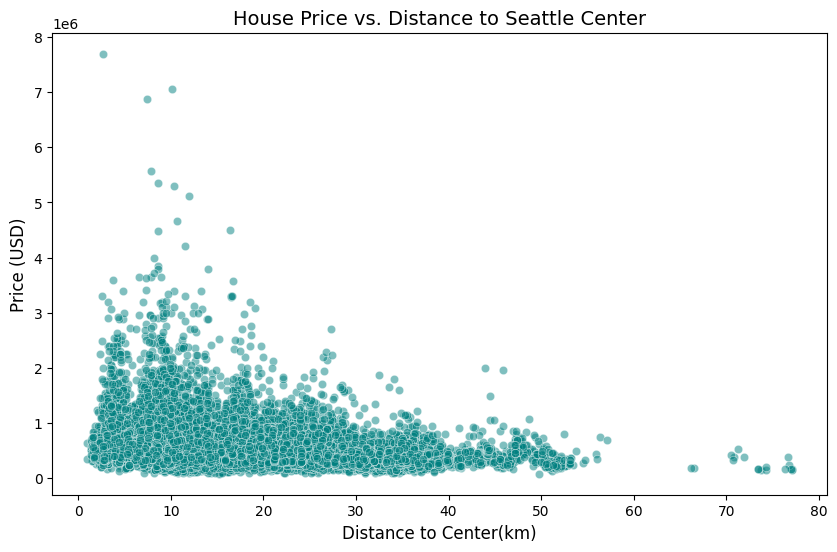

In [25]:
# Create a scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='dist_center', y='price', alpha=0.5, color='teal')

# Add titles and labels
plt.title('House Price vs. Distance to Seattle Center', fontsize=14)
plt.xlabel('Distance to Center(km)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.show()

### Test 4: Visualizing the Impact of Renovation on Price
We will use a bar plot to compare the average price of houses 
that were never renovated (0) against those that were renovated (1).
We expect renovated houses to have a higher average price.

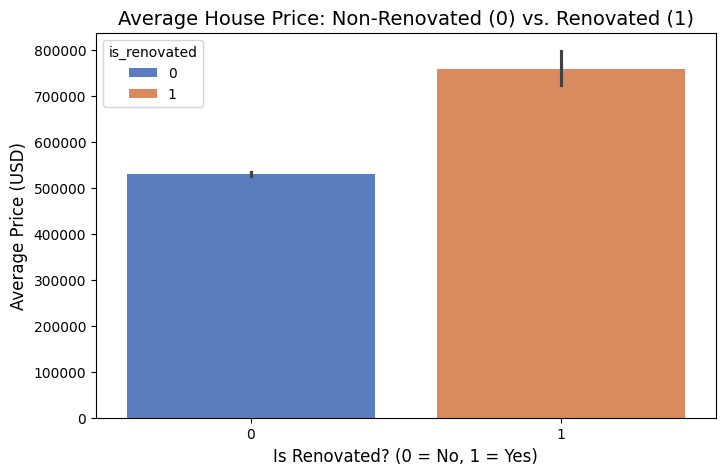

In [32]:
# Test 4: Comparing average prices using a bar plot
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='is_renovated', y='price',hue='is_renovated', palette='muted')

# Adding descriptive labels
plt.title('Average House Price: Non-Renovated (0) vs. Renovated (1)', fontsize=14)
plt.xlabel('Is Renovated? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)

# Show the plot
plt.show()

### Test 5: Visualizing House Age vs. Price (Colored by Renovation Status)
Now I will use a scatter plot to see the relationship between house age and price.
I will color the points based on whether the house was renovated or not.
This will help me visually verify if old, renovated houses maintain a high price.

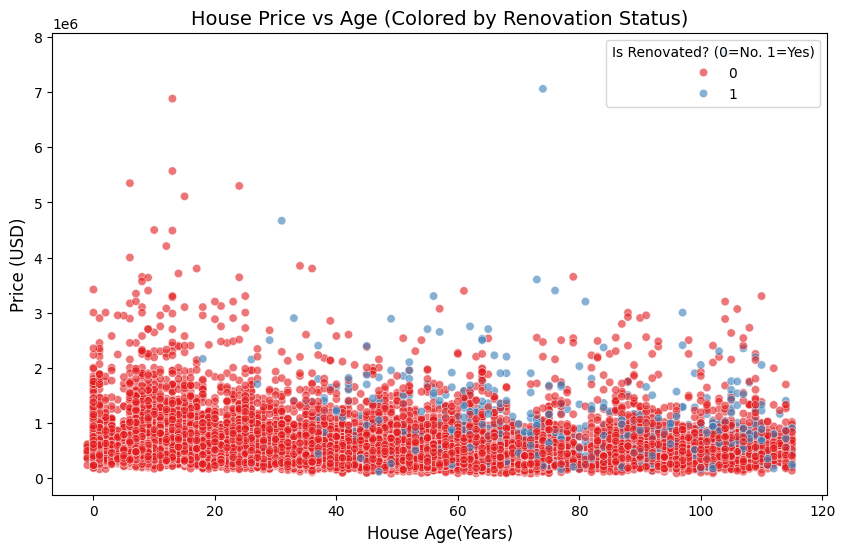

In [27]:
# test 5: Visualizing the interaction between age, price, and renovation 
plt.figure(figsize=(10,6))

# I'm plotting the scatter chart using 'hue' to color the points by renovation state
sns.scatterplot(data=df, x='house_age', y='price', hue='is_renovated', alpha=0.6, palette='Set1')

# Add descriptive labels to my chart
plt.title('House Price vs Age (Colored by Renovation Status)', fontsize=14)
plt.xlabel('House Age(Years)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='Is Renovated? (0=No. 1=Yes)')

plt.show()

### Test 6: Checking for Missing Values and Data Types
Before proceeding with feature engineering and modeling, I need to verify 
the quality of my dataset. I will check for null values and ensure all 
columns have the correct data types.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

### Test 7: Analyzing the Distribution of House Prices
In this test, I will plot a histogram to analyze how house prices are distributed.
This will help me identify if most houses are concentrated in a specific price range 
and look for asymmetry (skewness) in the target variable.

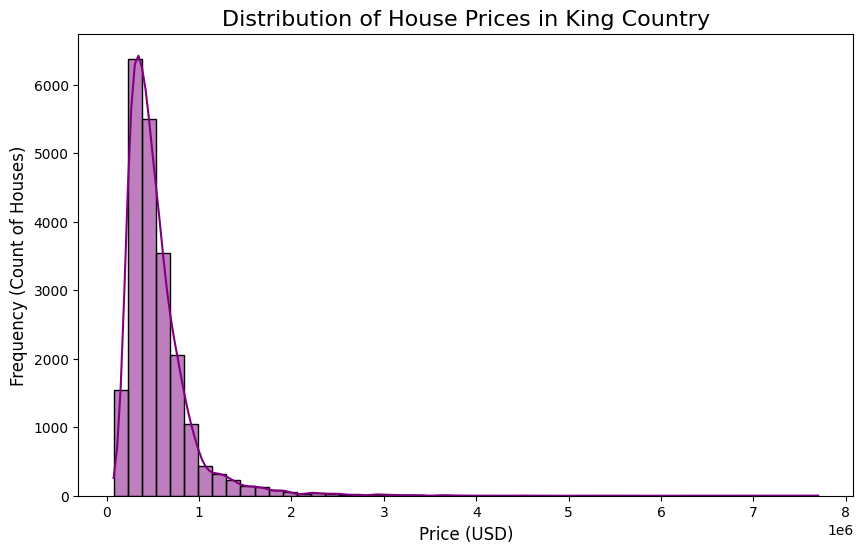

In [33]:
# Test 7: plotiing the price distribution
plt.figure(figsize=(10,6))

# I use hispplot to see the distribution curve of the prices
sns.histplot(data=df, x='price', kde=True, color='purple', bins=50)

# I add titles and labels
plt.title('Distribution of House Prices in King Country', fontsize=16)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Frequency (Count of Houses)', fontsize=12)

plt.show()

### Test 8: Visualizing Price Outliers with a Boxplot
In this test, I will use a Boxplot to visualize the concentration of house prices 
and clearly identify the outliers (extreme values) in the upper price ranges.

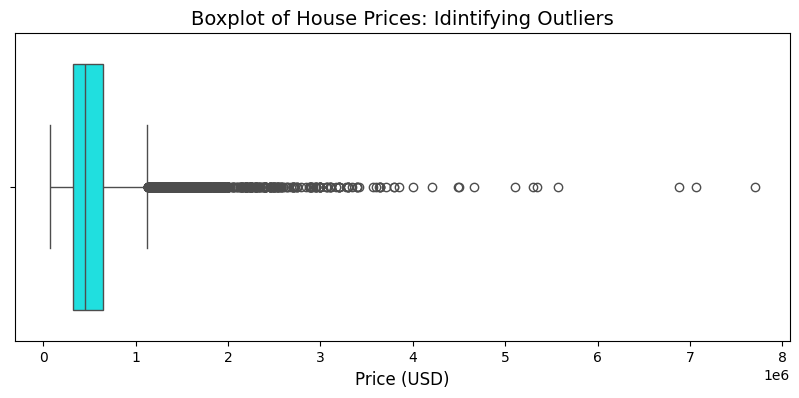

In [34]:
# Test 8: Plotting a boxplot for prices
plt.figure(figsize=(10,4))

# I use boxplot to see the median, quartiles, and outliers of the price
sns.boxplot(data=df, x='price', color='cyan')

# I add clear titles and labels
plt.title('Boxplot of House Prices: Idintifying Outliers', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)

plt.show()

### Test 9: House Prices vs. Number of Bedrooms
In this test, I will use multiple boxplots to analyze how the number of bedrooms 
affects the property price. This will help me understand if the size (rooms) 
has a linear impact on price compared to the renovation status.

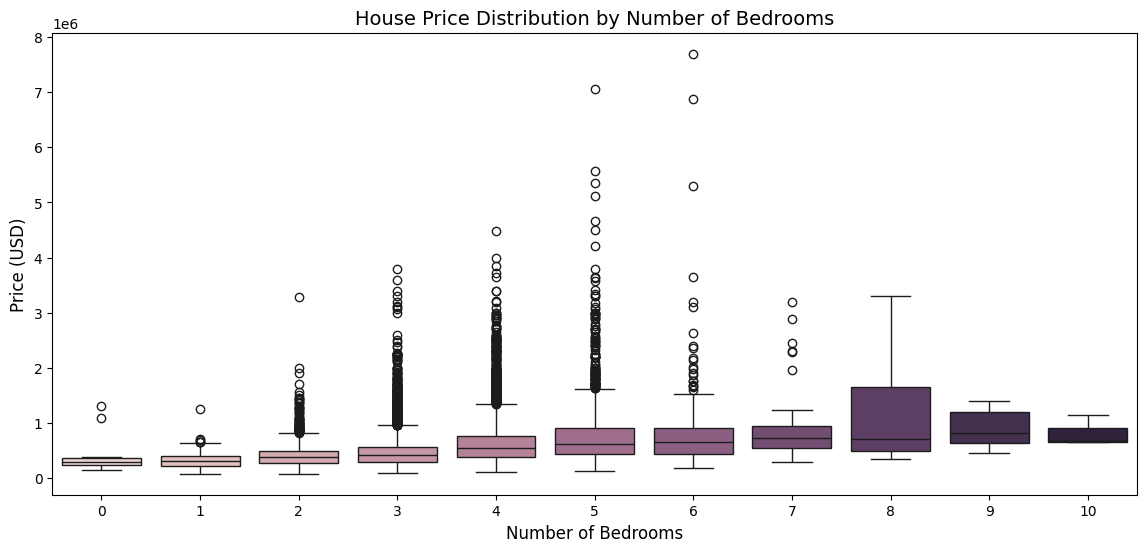

In [35]:
# test 0: Plotting price distribution by number of bedrooms
plt.figure(figsize=(14,6))

# I use a boxplot, settig bedrooms on the X axis and price on the Y axis
# Limiting the view up to 10 bedrooms to avoid exteme anomalies (like a 33-bedroom house)
sns.boxplot(data=df[df['bedrooms'] <=10], x='bedrooms', y='price', hue='bedrooms')

# Removing the legend manually o keep the chart clean
plt.gca().get_legend().remove()

# I add clear titles and labels
plt.title('House Price Distribution by Number of Bedrooms', fontsize=14)
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.show()

### Test 10: Preparing Data for Machine Learning (Train/Test Split)
Now I will isolate the target variable (price) from the features, drop 
unnecessary columns like 'id' and 'date', and split the dataset into 
80% for training and 20% for testing.

In [ ]:
# Test 10: Splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# i separete the features (x) by dropping columns that don't help predic price
# I also drop 'yr_renovated' since I already created 'is_renovated' from it
X= df.drop(columns=['price', 'id', 'date', 'yr_renovated'])

# I isolate the target variable (y) wich is the price we want to predict
y = df['price']

# I split the data into 89% training and 20% testing
# Using random_state=42 ensures that the split is reproducible ebery time I run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the generated datasets to verify the split
print(f'Training features shape: {X_train.shape}\n'
      f'Testing features shape: {X_test.shape}')



Training features shape: (17290, 20)
Testing features shape: (4323, 20)


## Phase 2: Model Training & Evaluation Strategy

To find the best predictive model for house prices in King County, I will implement 
a benchmark strategy. I am going to train three different types of machine learning 
algorithms, ranging from simpler linear models to advanced ensemble methods. 

I will evaluate and compare their performance using metrics like **R² Score** (Explained Variance) and **MAE** (Mean Absolute Error) to select the absolute winner.

### Machine Learning Models to be Deployed:
1. **Linear Regression:** My baseline model to set the initial performance standard.
2. **Random Forest Regressor:** A powerful ensemble of decision trees to capture non-linear patterns.
3. **XGBoost Regressor / LightGBM:** State-of-the-art gradient boosting algorithms for maximum accuracy.

### Test 11: Training our First Machine Learning Model (Linear Regression)
With the training data ready, I will now import the Linear Regression algorithm, 
initialize it, and train (fit) the model using the training features and target.

In [41]:
# Test 11: Importing and training the Linear Regression model
from sklearn.linear_model import LinearRegression

# 1. Initialize the model
model = LinearRegression()

# 2. Train model using my training data 
model.fit(X_train, y_train)

print('Model successfully trained: Your fist AI is ready to make predictions.')

Model successfully trained: Your fist AI is ready to make predictions.
